# Outlier Detection using the Percentile Method | Winsorization Technique

In [115]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [116]:
df = pd.read_csv("https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/refs/heads/main/day44-outlier-detection-using-percentiles/weight-height.csv")

In [117]:
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [118]:
df.shape

(10000, 3)

In [119]:
df["Height"].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

<Axes: xlabel='Height', ylabel='Count'>

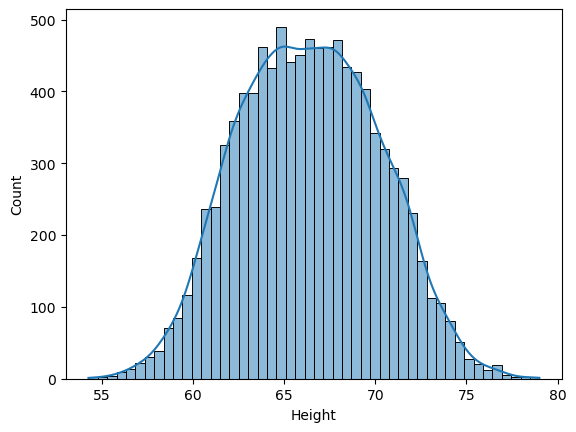

In [120]:
sns.histplot(df['Height'], kde=True)

In [121]:
sk = df["Height"].skew()
print(sk)

0.04936908937689031


<Axes: ylabel='Height'>

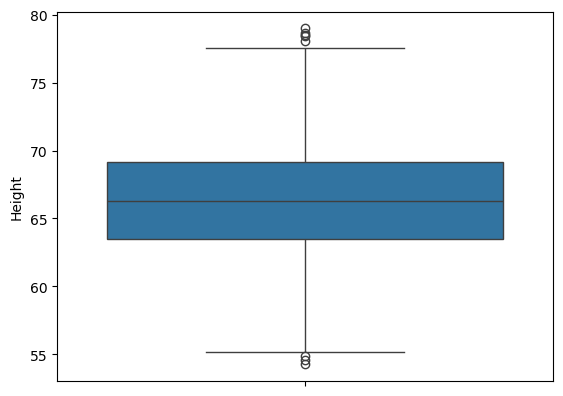

In [122]:
sns.boxplot(df['Height'])

## Trimming 

In [123]:
upper_limit = df['Height'].quantile(0.99)
upper_limit

np.float64(74.7857900583366)

In [124]:
lower_limit = df['Height'].quantile(0.01)
lower_limit

np.float64(58.13441158671655)

In [125]:
new_df = df[(df['Height'] <= 74.78) & (df['Height'] >= 58.13)]

In [126]:
new_df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [127]:
new_df["Height"].describe()

count    9799.000000
mean       66.363507
std         3.644267
min        58.134496
25%        63.577147
50%        66.317899
75%        69.119859
max        74.767447
Name: Height, dtype: float64

In [128]:
df["Height"].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

<Axes: xlabel='Height', ylabel='Count'>

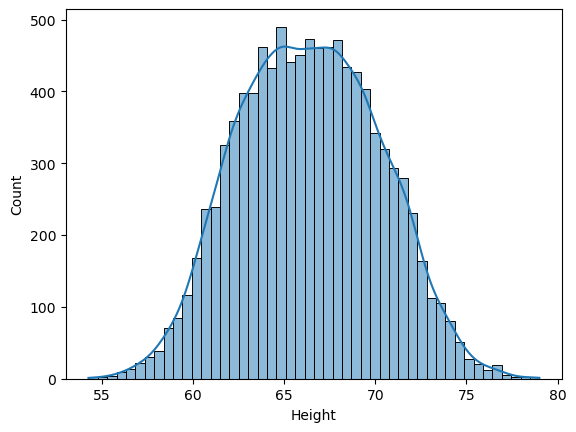

In [129]:
sns.histplot(df['Height'], kde=True)

<Axes: ylabel='Height'>

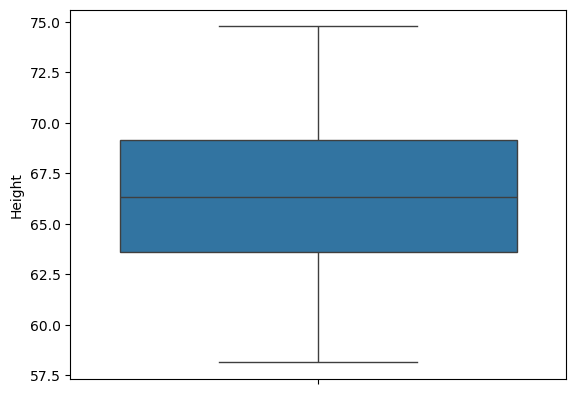

In [130]:
sns.boxplot(new_df['Height'])

## # Capping --> Winsorization

In [131]:
df['Height'] = np.where(df['Height'] >= upper_limit,
        upper_limit,
        np.where(df['Height'] <= lower_limit,
        lower_limit,
        df['Height']))

In [132]:
df.shape

(10000, 3)

In [133]:
df['Height'].describe()

count    10000.000000
mean        66.366281
std          3.795717
min         58.134412
25%         63.505620
50%         66.318070
75%         69.174262
max         74.785790
Name: Height, dtype: float64

<Axes: xlabel='Height', ylabel='Count'>

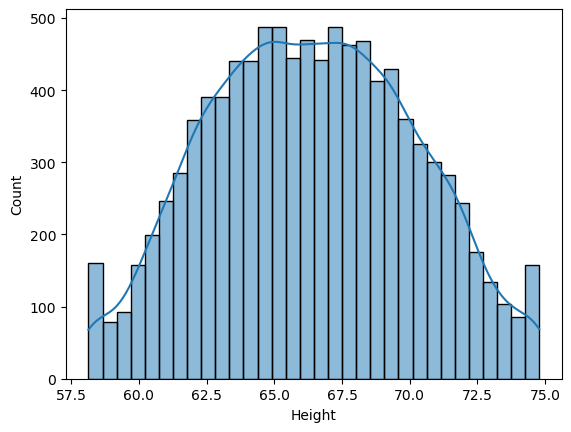

In [134]:
sns.histplot(df['Height'], kde=True)

<Axes: ylabel='Height'>

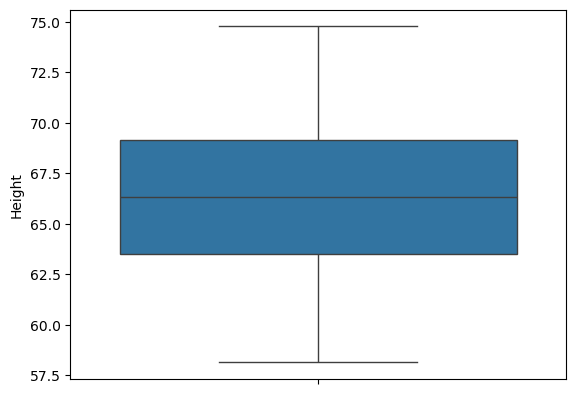

In [135]:
sns.boxplot(df['Height'])